# YOLOv7 Proof-of-Concept Experiment for ADAS Perception

This notebook demonstrates object detection using YOLOv7 on urban road scenes for ADAS perception by downloading multiple road-scene images automatically and runing **YOLOv7** on all of them.

## 1. Clone YOLOv7 and Install Dependencies

In [ ]:
!git clone https://github.com/WongKinYiu/yolov7
%cd yolov7
!pip install -q torch torchvision opencv-python pillow matplotlib pyyaml scipy tqdm seaborn pandas requests
!wget -q -O yolov7.pt https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt


Cloning into 'yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197 (from 1)
Receiving objects: 100% (1197/1197), 74.29 MiB | 22.51 MiB/s, done.
Resolving deltas: 100% (513/513), done.
/content/yolov7


## 2. Patch the Loader for Newer PyTorch Versions

In [ ]:
from pathlib import Path

p = Path("models/experimental.py")
text = p.read_text()
text = text.replace(
    "ckpt = torch.load(w, map_location=map_location)  # load",
    "ckpt = torch.load(w, map_location=map_location, weights_only=False)  # load"
)
p.write_text(text)
print("Patched experimental.py")


Patched experimental.py


## 3. Download Multiple Example Images Automatically

In [ ]:
import requests
from pathlib import Path

image_urls = [
    "https://plus.unsplash.com/premium_photo-1733263230987-de816feabf26?q=80&w=2070&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # Chicago street
    "https://images.unsplash.com/photo-1701518043851-4dab3207f78b?q=80&w=1035&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # highway sign car
    "https://images.unsplash.com/photo-1579653384681-c3ba17c4a8c9?q=80&w=862&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # city buildings road
    "https://images.unsplash.com/photo-1614685862822-f8fa20f87175?q=80&w=3132&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"   # pedestrians crossing
]

input_dir = Path("real_inputs")
input_dir.mkdir(exist_ok=True)

for i, url in enumerate(image_urls, start=1):
    img_path = input_dir / f"image_{i}.jpg"

    try:
        if not img_path.exists():
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                with open(img_path, "wb") as f:
                    f.write(response.content)
            else:
                print(f"Skipped (error {response.status_code}): {url}")
    except Exception as e:
        print(f"Failed: {url}")

print("Downloaded images:")
for f in input_dir.iterdir():
    print("-", f.name)


Downloaded images:
- image_4.jpg
- image_3.jpg
- image_2.jpg
- image_1.jpg


## 4. Run YOLOv7 on All Images

In [ ]:
!python detect.py --weights yolov7.pt --source real_inputs --conf-thres 0.15 --project runs/detect --name adas_multi --exist-ok


Namespace(weights=['yolov7.pt'], source='real_inputs', img_size=640, conf_thres=0.15, iou_thres=0.45, device='', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='adas_multi', exist_ok=True, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.10.0+cpu CPU

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
Model Summary: 306 layers, 36905341 parameters, 6652669 gradients
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
20 persons, 10 cars, 1 truck, 4 traffic lights, 2 umbrellas, 1 handbag, 2 c

## 5. Display the Detection Outputs

Detection outputs:
- image_1.jpg
- image_2.jpg
- image_3.jpg
- image_4.jpg


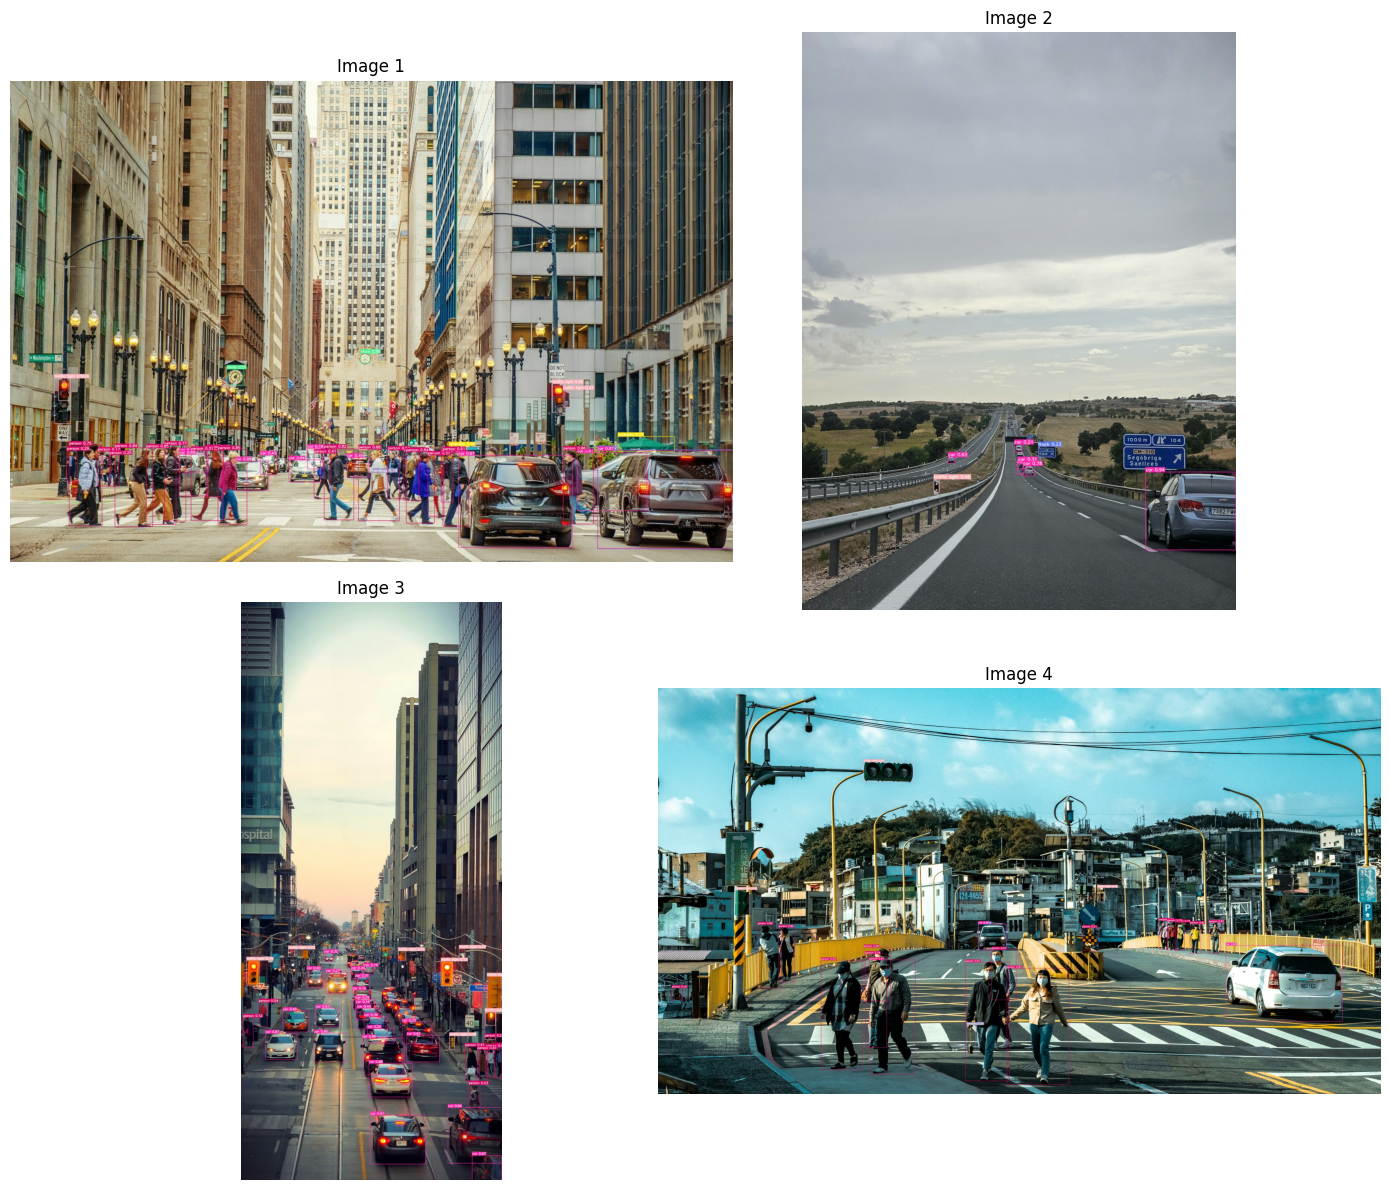

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

output_dir = Path("runs/detect/adas_multi")
output_files = sorted(list(output_dir.glob("*.png")) + list(output_dir.glob("*.jpg")))

print("Detection outputs:")
for f in output_files:
    print("-", f.name)

plt.figure(figsize=(14, 12))
for i, f in enumerate(output_files, 1):
    plt.subplot(2, 2, i)
    plt.imshow(Image.open(f))
    plt.title(f.stem.replace("_", " ").title())
    plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Download the Detection Outputs

In [ ]:
from google.colab import files

for f in sorted(output_dir.glob("*")):
    files.download(str(f))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for the Report

- This notebook runs YOLOv7 on **multiple real-world road scenes**.
- The images are downloaded automatically, so there is no need to upload them manually.
